# 02 — Exploratory Data Analysis

**Phase 2.** What the EduPro data actually looks like, and what that means for the
segmentation and recommendation work.

Figures are produced by `scripts/generate_eda_figures.py` into `artifacts/eda/` and
displayed here, so the notebook, the research paper and the dashboard cannot show
different versions of the same chart.

In [1]:
import json

import numpy as np
import pandas as pd
from IPython.display import Image, display

from edupro import config
from edupro.data.joins import build_interactions, course_popularity
from edupro.data.loader import load_all
from edupro.features.learner import build_learner_features, summarise_features

EDA = config.ARTIFACTS_DIR / "eda"
data = load_all()
interactions = build_interactions(data, with_user_demographics=True, with_teacher=True)
counts = data.transactions.groupby("UserID").size()
popularity = course_popularity(interactions)
audit = json.loads((config.ARTIFACTS_DIR / "phase2_audit.json").read_text(encoding="utf-8"))
print(f"{len(data.users):,} learners · {len(data.courses)} courses · "
      f"{len(data.transactions):,} interactions")

3,000 learners · 60 courses · 10,000 interactions


## 1. Learner activity

The distribution is **bimodal with an empty band at 5–8 interactions**. No sampling
process produces a gap like that: it is a property of how the data was generated.
Two cohorts exist — a light cohort (1–4) holding 85% of learners but 39% of
interactions, and a heavy cohort (9–16) with the reverse.

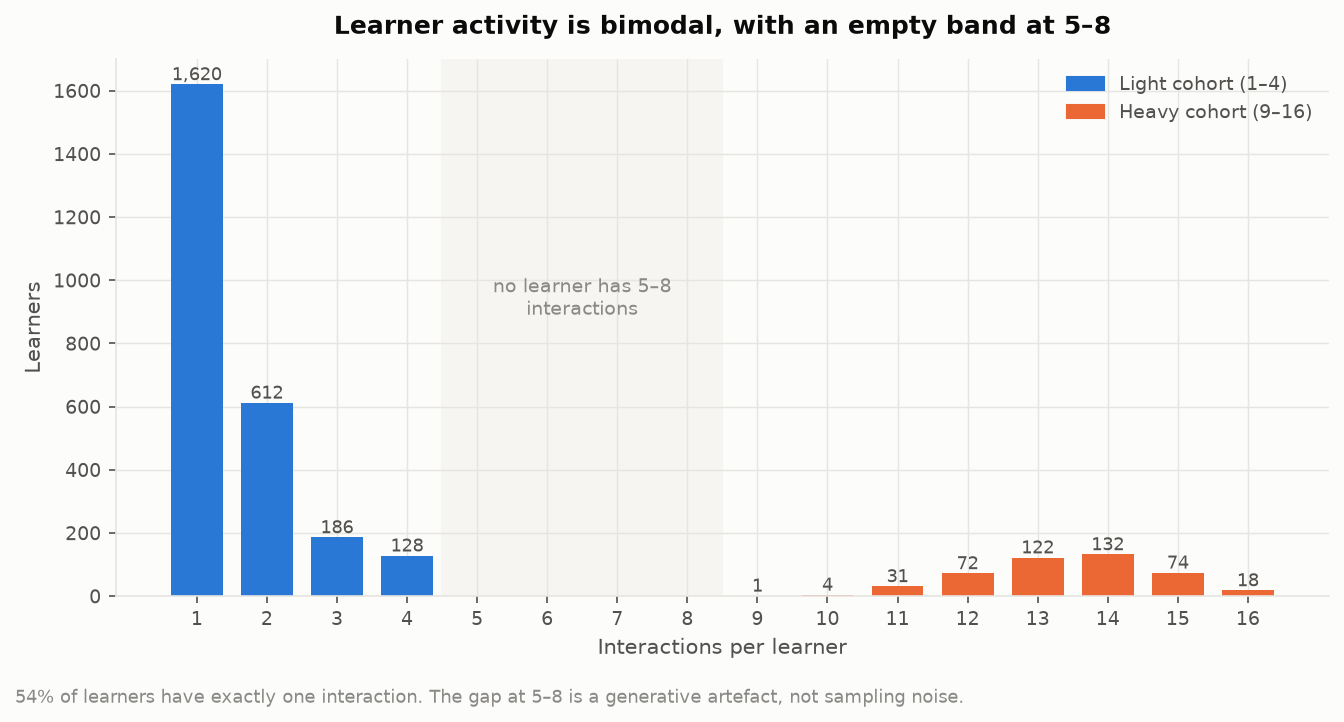

light cohort (1-4) : 2,546 learners (84.9%), 3,914 interactions (39.1%)
heavy cohort (9-16): 454 learners (15.1%), 6,086 interactions (60.9%)


In [2]:
display(Image(filename=str(EDA / "01_interaction_distribution.png")))

light, heavy = counts[counts <= 4], counts[counts >= 9]
print(f"light cohort (1-4) : {len(light):,} learners ({len(light)/len(counts)*100:.1f}%), "
      f"{light.sum():,} interactions ({light.sum()/counts.sum()*100:.1f}%)")
print(f"heavy cohort (9-16): {len(heavy):,} learners ({len(heavy)/len(counts)*100:.1f}%), "
      f"{heavy.sum():,} interactions ({heavy.sum()/counts.sum()*100:.1f}%)")

## 2. Course popularity is almost perfectly flat

Enrollments per course range only 140–196 around an expectation of 166.7, with a
Gini of 0.042. A chi-square test against uniform does not reject (p = 0.60).

**This matters more than it looks.** Popularity is normally a strong recommendation
baseline; here it carries almost no ranking information, so a popularity recommender
will behave close to random.

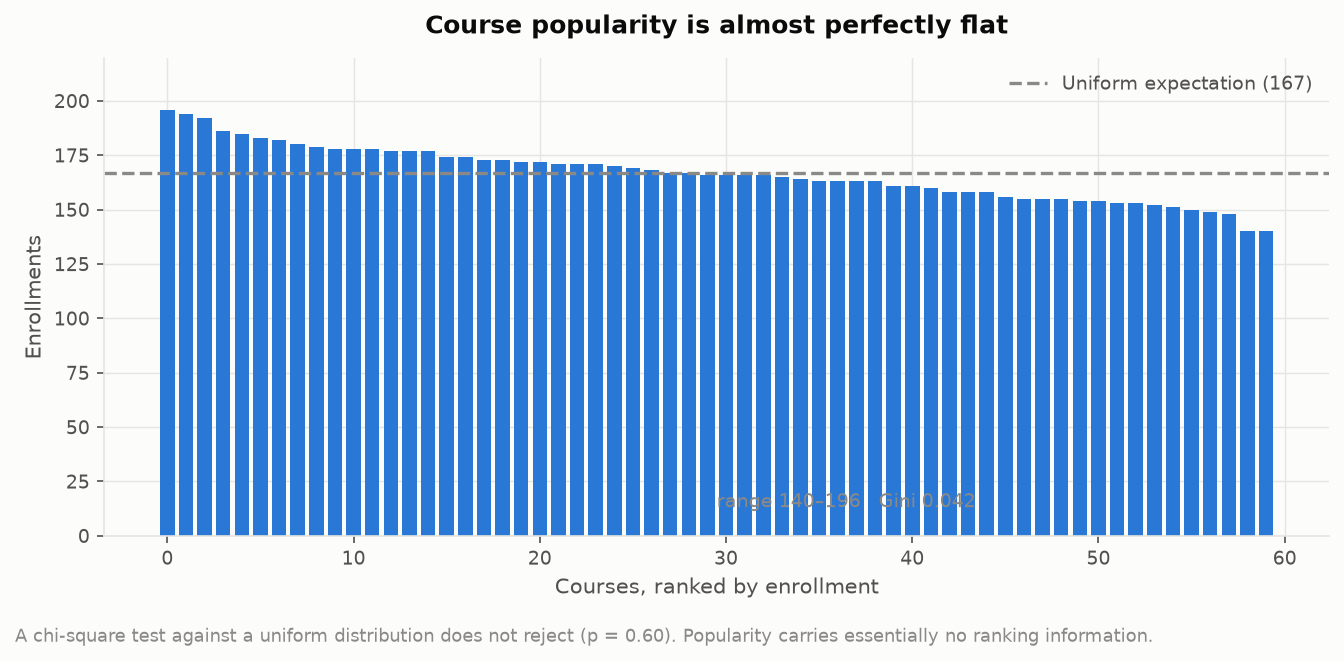

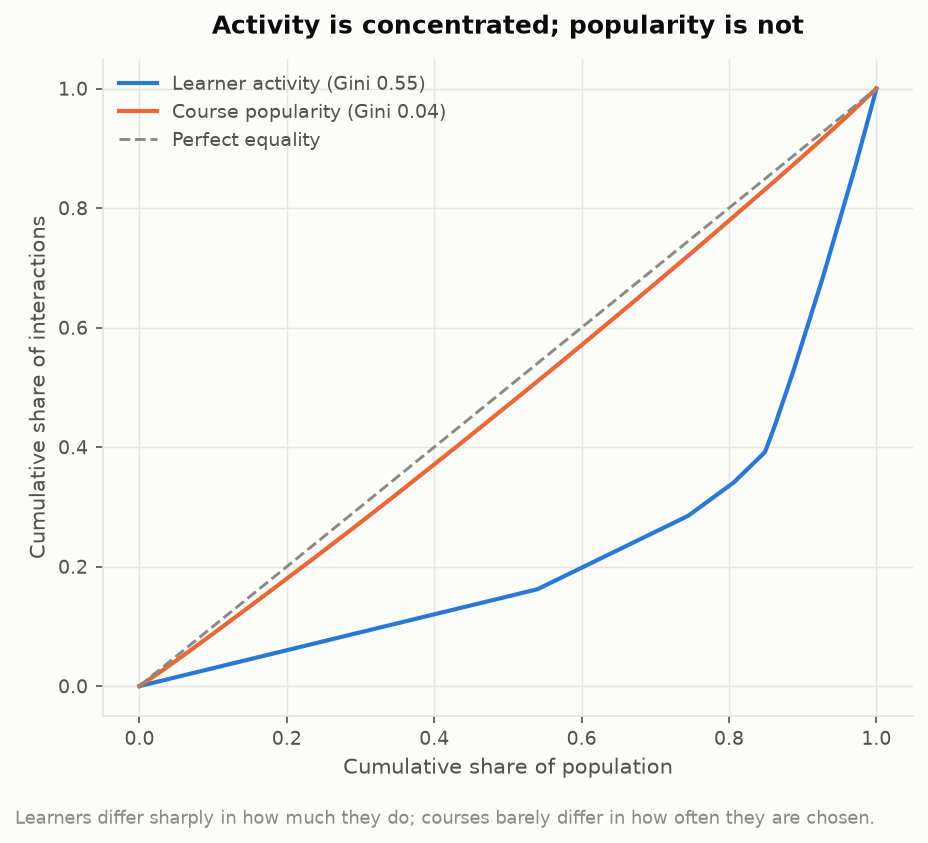

count     60.00
mean     166.67
std       12.52
min      140.00
25%      157.50
50%      166.00
75%      174.75
max      196.00


In [3]:
display(Image(filename=str(EDA / "02_course_popularity.png")))
display(Image(filename=str(EDA / "03_lorenz_concentration.png")))
print(popularity.describe().round(2).to_string())

## 3. The catalogue is perfectly balanced

Exactly five courses in each of the twelve categories. 38 free / 22 paid, and
`CourseType` is a deterministic function of `CoursePrice` (Free ⟺ price = 0).

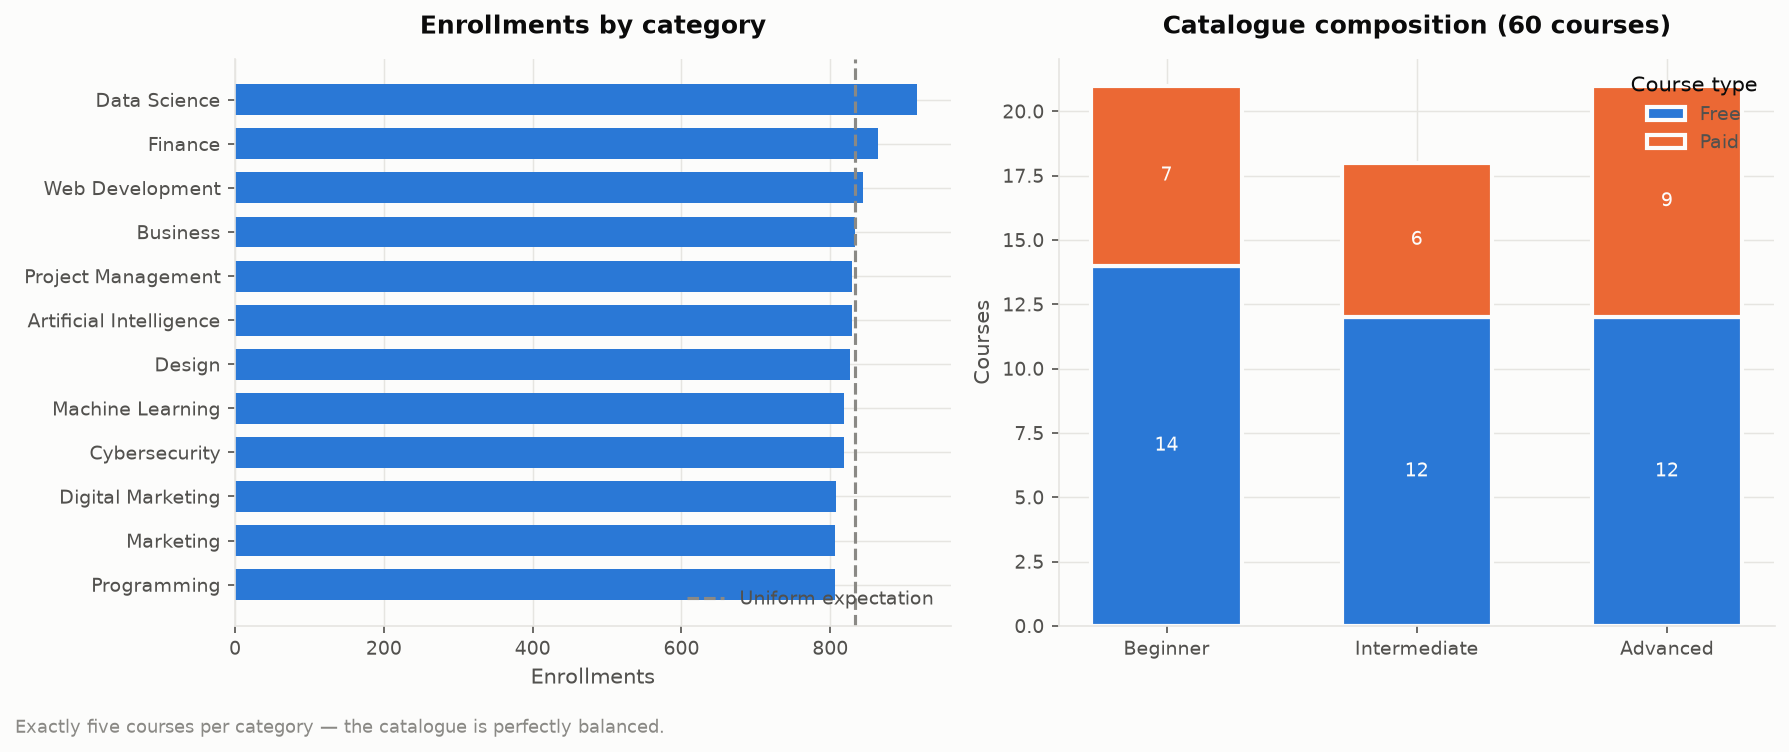

,courses,mean_price,mean_rating,mean_duration,enrollments
CourseCategory,,,,,
Data Science,5,83.45,3.32,27.99,916
Finance,5,34.58,3.01,28.69,864
Web Development,5,19.04,2.85,39.49,844
Business,5,219.80,2.69,24.05,833
Project Management,5,203.46,3.14,16.47,829
Artificial Intelligence,5,248.82,3.04,17.91,829
Design,5,55.27,3.16,32.77,827
Cybersecurity,5,78.85,2.90,36.31,819
Machine Learning,5,0.16,2.66,31.36,819


In [4]:
display(Image(filename=str(EDA / "04_catalogue_composition.png")))
summary = data.courses.groupby(["CourseCategory"]).agg(
    courses=("CourseID", "size"),
    mean_price=("CoursePrice", "mean"),
    mean_rating=("CourseRating", "mean"),
    mean_duration=("CourseDuration", "mean"),
).round(2)
summary["enrollments"] = data.transactions.merge(
    data.courses[["CourseID", "CourseCategory"]], on="CourseID"
).groupby("CourseCategory").size()
summary.sort_values("enrollments", ascending=False)

## 4. Time

Twelve months of 2025, 358 distinct days, no trend and no seasonality. Monthly
volume varies by under 10% around the mean — convenient for a temporal split, since
no period is unrepresentative.

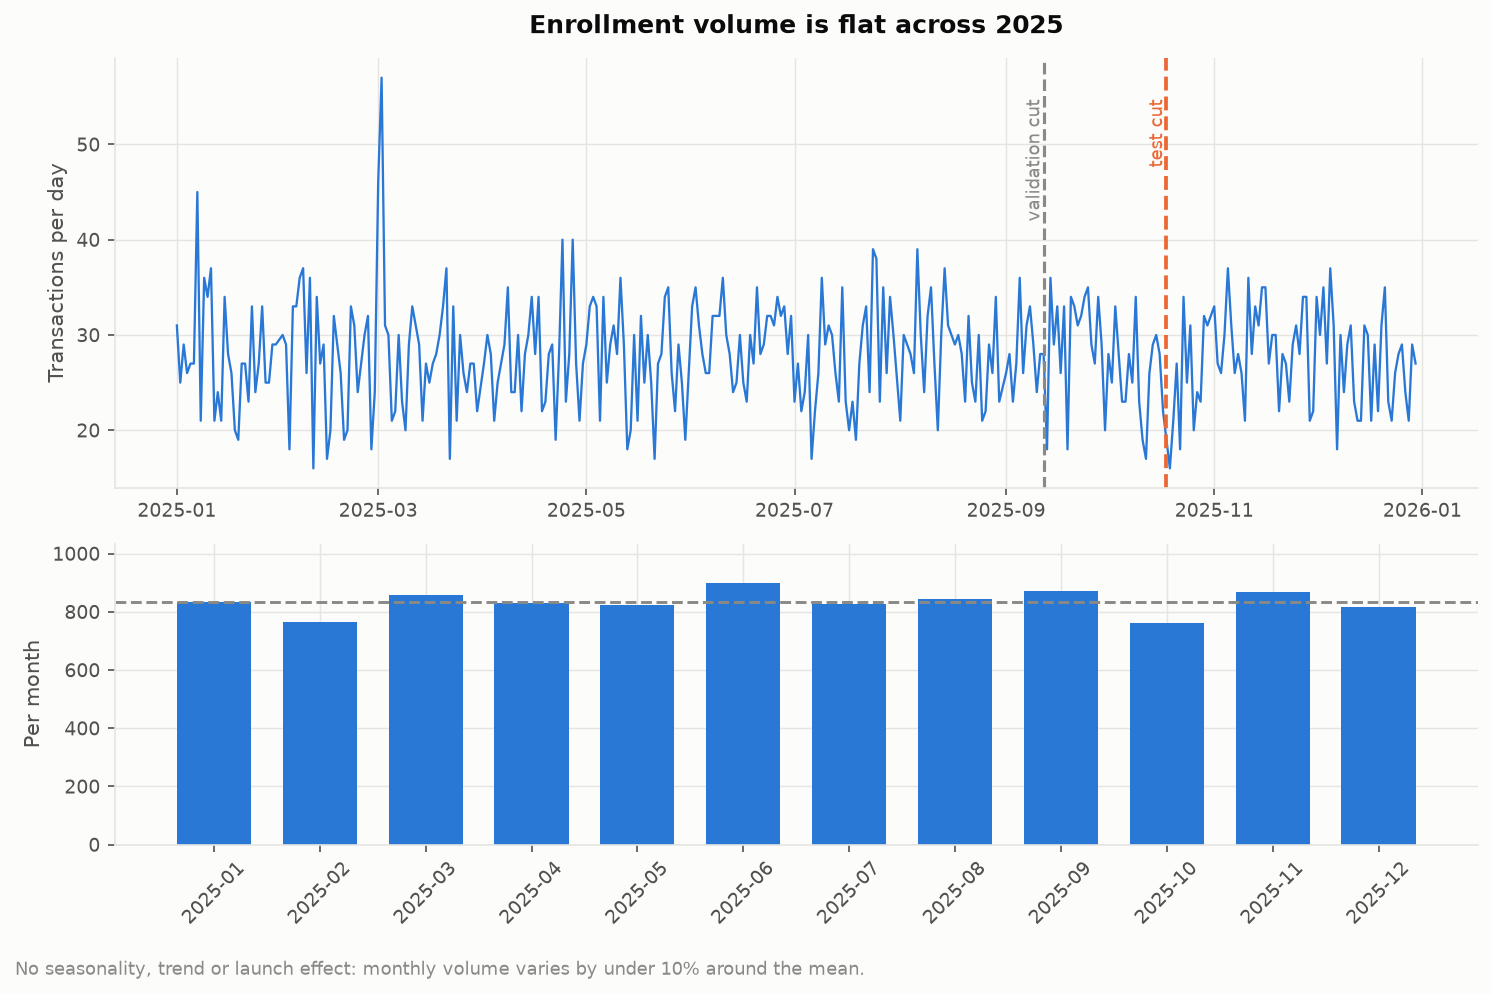

span            : 2025-01-01 .. 2025-12-30 (358 days)
validation cut  : 2025-09-12
test cut        : 2025-10-18
evaluable (A)   : 791  -> primary protocol A (global temporal)


In [5]:
display(Image(filename=str(EDA / "05_temporal_activity.png")))
e4 = audit["EXP-004_temporal_split"]
print(f"span            : {e4['date_min']} .. {e4['date_max']} ({e4['n_distinct_dates']} days)")
print(f"validation cut  : {e4['validation_date']}")
print(f"test cut        : {e4['test_date']}")
print(f"evaluable (A)   : {e4['n_evaluable_learners']:,}  -> primary protocol {e4['primary_protocol']}")

## 5. Is there any personalisation signal? (the decisive question)

Each observed statistic is compared against a **permutation null** in which each
learner's courses are redrawn from the empirical popularity distribution with that
learner's history length held fixed. If the observed value falls inside the null
interval, the data carries no preference signal on that dimension.

**Result: course choice is indistinguishable from popularity-weighted chance.**
Teacher choice is not.

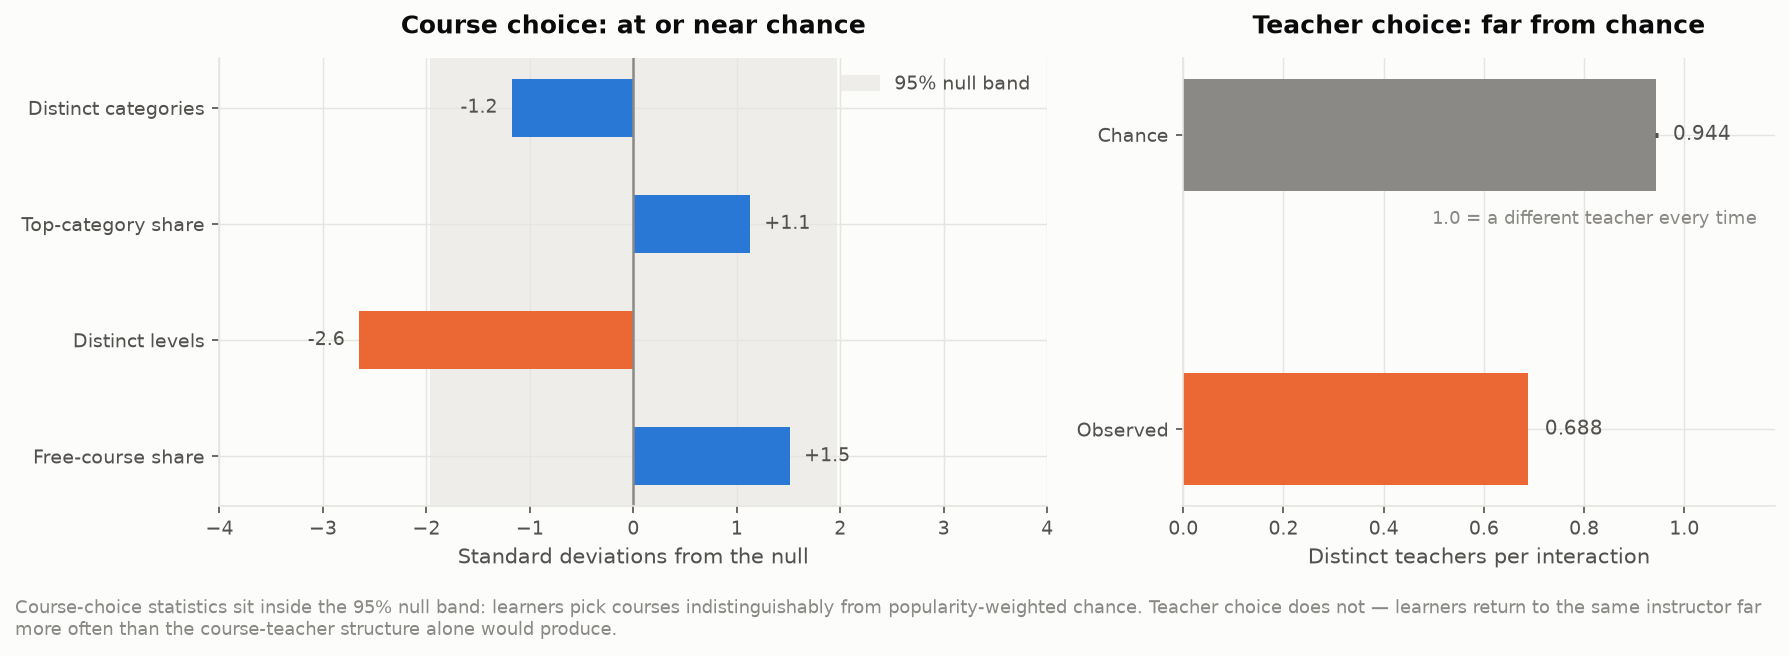

,observed,null_mean,null_lo,null_hi,z,signal
statistic,,,,,,
mean_distinct_categories,2.5773,2.5869,2.5710,2.6017,-1.1720,False
mean_top_category_share,0.7210,0.7194,0.7169,0.7223,1.1250,False
mean_distinct_levels,1.5560,1.5707,1.5600,1.5817,-2.6483,True
mean_free_share,0.6501,0.6394,0.6261,0.6539,1.5095,False


In [6]:
display(Image(filename=str(EDA / "06_signal_detection.png")))

rows = []
for name, result in audit["signal_detection"]["preference_vs_popularity_null"].items():
    rows.append({
        "statistic": name, "observed": result["observed"], "null_mean": result["null_mean"],
        "null_lo": result["null_ci_95"][0], "null_hi": result["null_ci_95"][1],
        "z": result["z"], "signal": result["signal"],
    })
pd.DataFrame(rows).set_index("statistic").round(4)

In [7]:
# Demographics carry no association with what learners choose.
pd.DataFrame(audit["signal_detection"]["demographics_vs_choice"]).T

,chi2,dof,p_value,dependent
gender_x_category,8.774,11,0.642741,False
gender_x_level,0.1978,2,0.905841,False
ageband_x_category,33.1705,33,0.458947,False
ageband_x_level,8.4284,6,0.208365,False


## 6. Learner demographics

Age is uniform over 15–35; gender is near-balanced. Neither is associated with
course choice (all chi-square p > 0.2 above), which is direct evidence for the
Variant B (behaviour-only) segmentation — to be confirmed by EXP-011, not assumed.

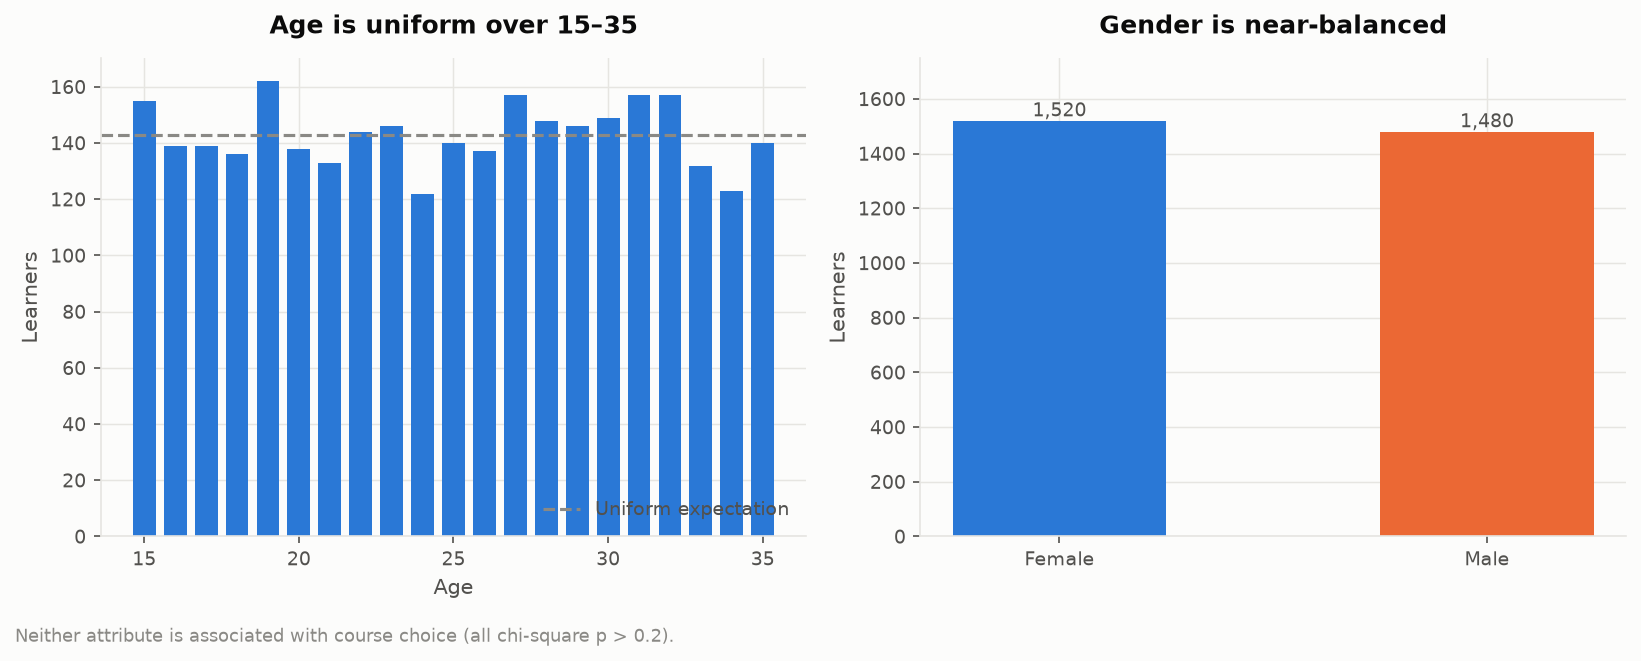

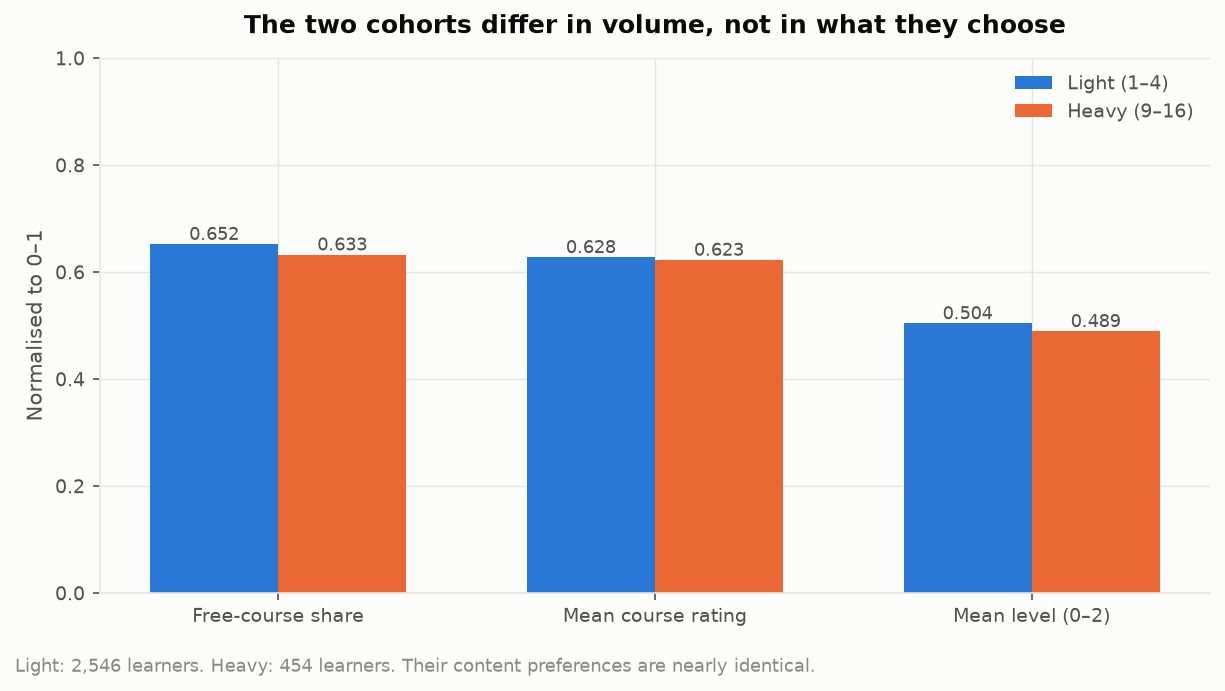

In [8]:
display(Image(filename=str(EDA / "07_demographics.png")))
display(Image(filename=str(EDA / "10_cohort_comparison.png")))

## 7. Candidate learner features

All eleven official features are implemented, plus justified additions. The
correlation structure is the problem: `total_courses` correlates above 0.9 with
diversity, entropy and teacher loyalty. Most candidate features largely re-measure
**activity volume**.

In [9]:
features = build_learner_features(interactions, users=data.users)
print(f"{features.shape[0]:,} learners x {features.shape[1]} features")
summarise_features(features).drop(columns=["count"]).head(22)

3,000 learners x 34 features


,mean,std,min,25%,50%,75%,max,skew,pct_zero,n_unique
total_courses,3.333333,4.352149,1.0,1.0,1.0,3.0,16.0,1.8809,0.0,12
diversity_score,2.577333,2.727606,1.0,1.0,1.0,2.0,11.0,1.8108,0.0,11
avg_courses_per_category,1.112946,0.2505,1.0,1.0,1.0,1.0,3.25,2.3581,0.0,33
activity_span_days,91.589,124.377058,0.0,0.0,0.0,189.0,363.0,0.9538,54.0667,353
enrollment_frequency,0.560772,0.481336,0.005747,0.035714,1.0,1.0,2.0,-0.1674,0.0,646
avg_course_rating,3.133471,0.950163,1.13,2.57,3.123259,3.795,4.94,-0.0861,0.0,1069
category_entropy,0.806278,1.081829,0.0,0.0,0.0,1.0,3.392747,1.1104,55.4667,94
top_category_share,0.72102,0.326817,0.125,0.5,1.0,1.0,1.0,-0.488,0.0,23
avg_spend,89.345012,125.054785,0.0,0.0,26.93,133.465,490.9,1.5366,46.5,705
total_spend,303.77449,482.513859,0.0,0.0,53.86,415.51,3054.37,2.1318,46.5,590


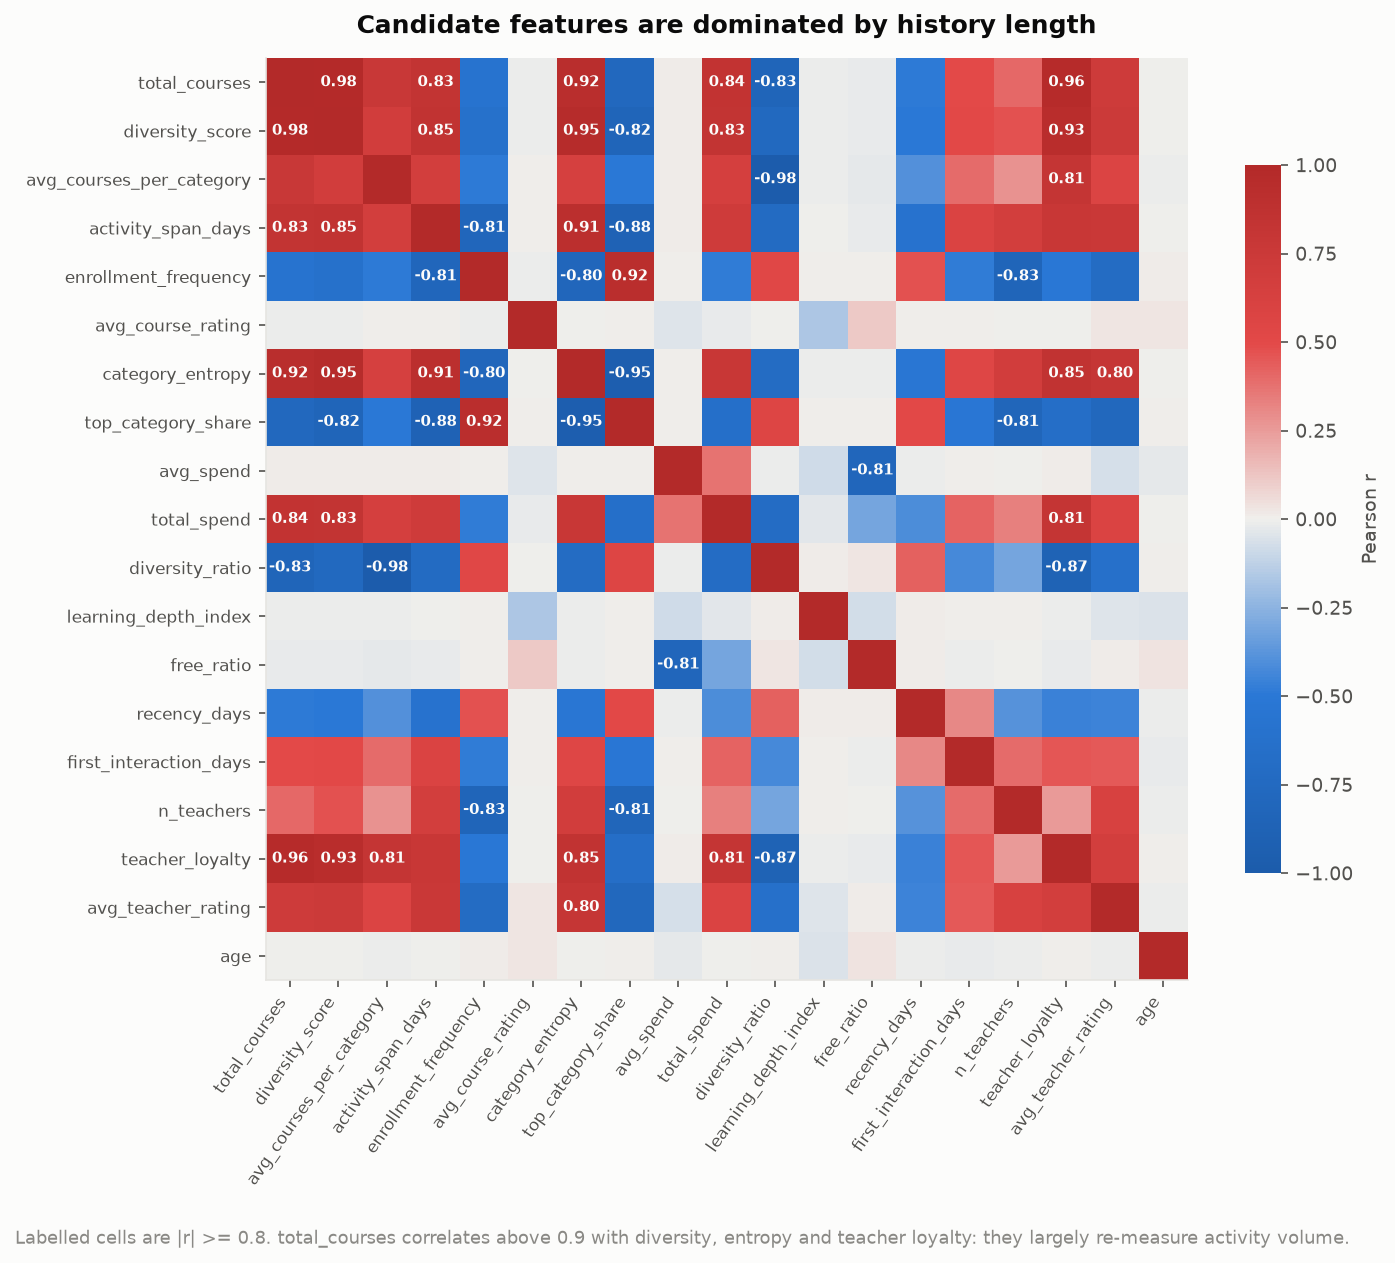

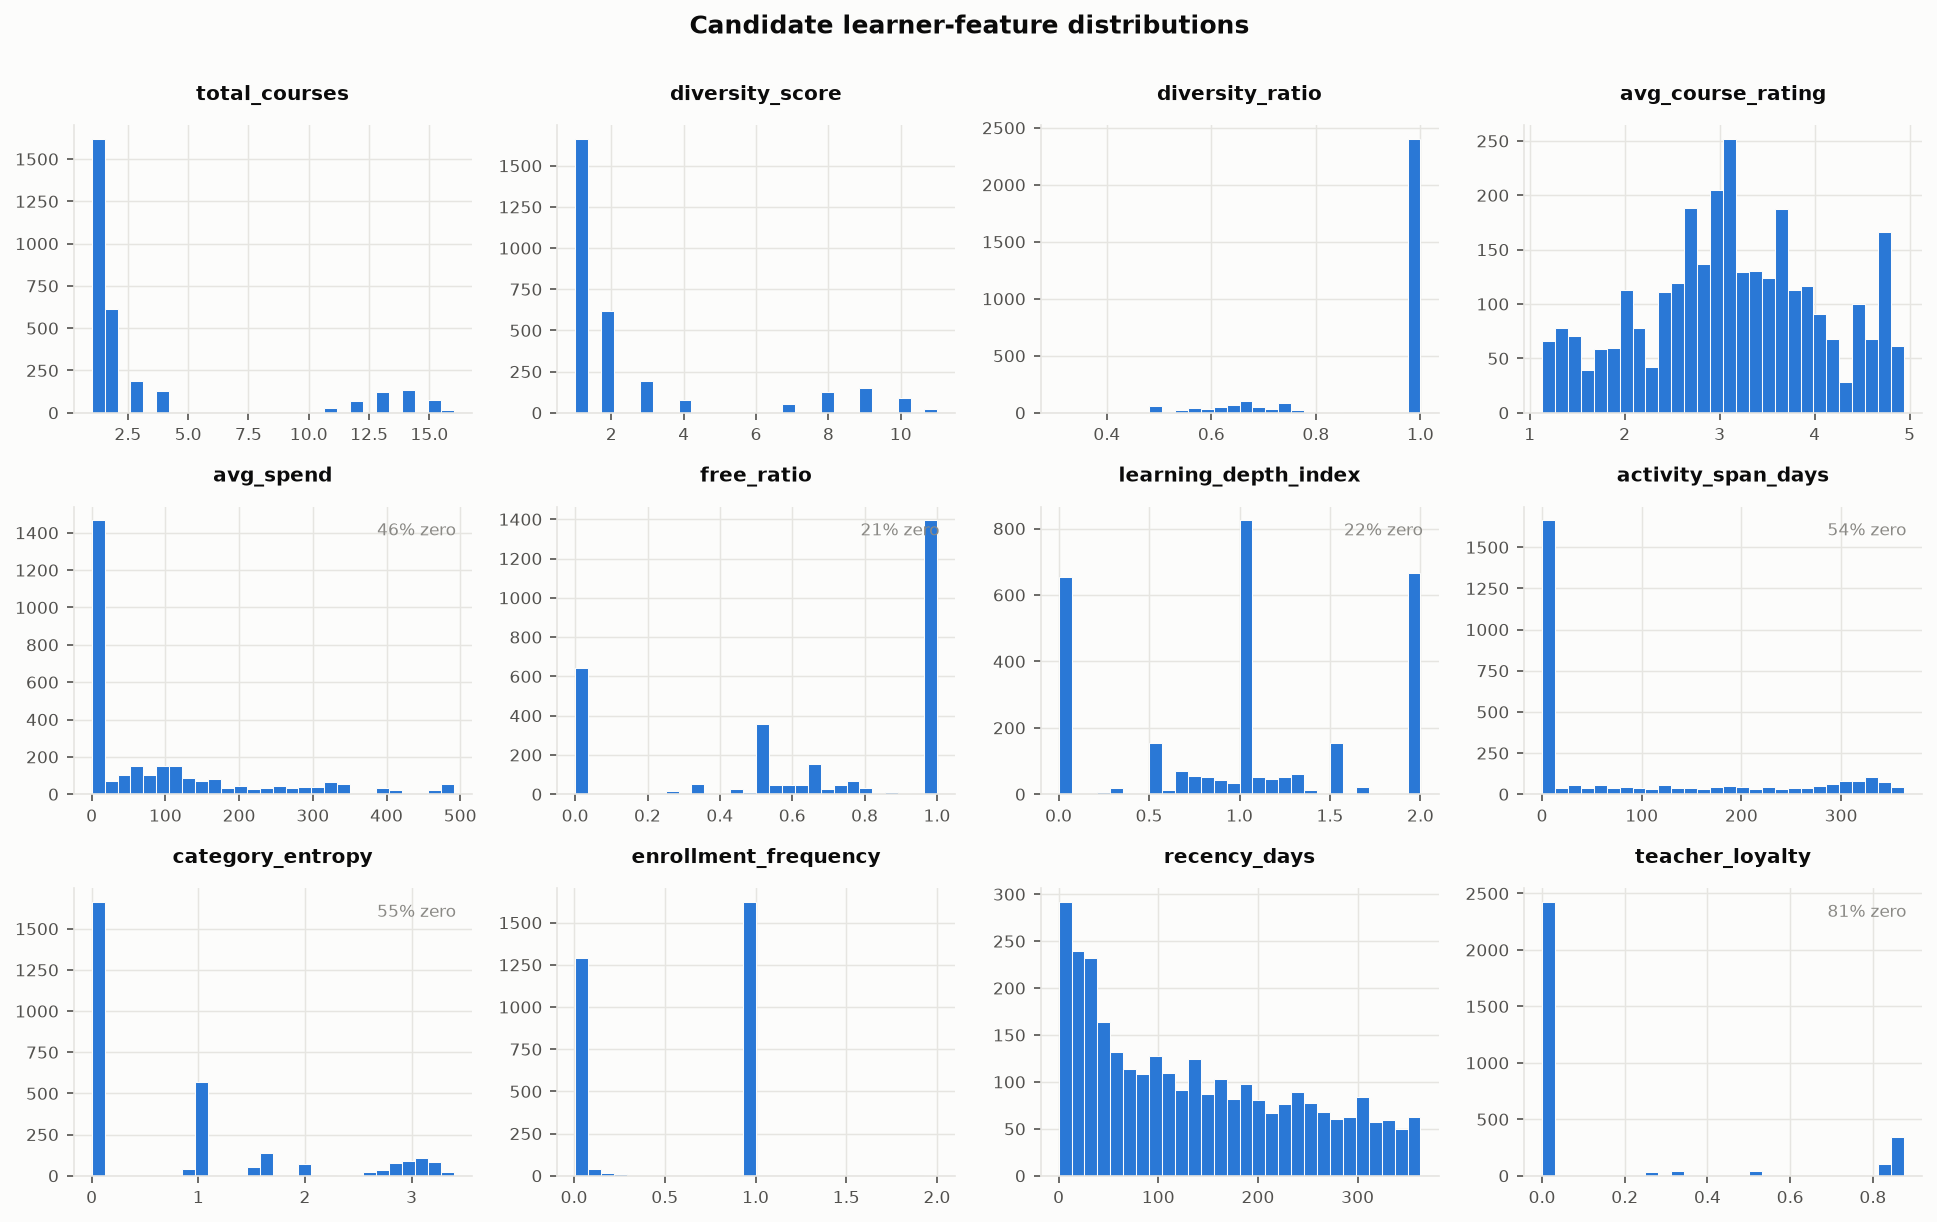

strongest redundancies (|r| >= 0.9):
  avg_courses_per_category   ~ diversity_ratio            r = -0.984
  total_courses              ~ diversity_score            r = +0.983
  total_courses              ~ teacher_loyalty            r = +0.963
  diversity_score            ~ category_entropy           r = +0.955
  category_entropy           ~ top_category_share         r = -0.951
  diversity_score            ~ teacher_loyalty            r = +0.933
  total_courses              ~ category_entropy           r = +0.924
  enrollment_frequency       ~ top_category_share         r = +0.917
  activity_span_days         ~ category_entropy           r = +0.910


In [10]:
display(Image(filename=str(EDA / "08_feature_correlation.png")))
display(Image(filename=str(EDA / "09_feature_distributions.png")))

print("strongest redundancies (|r| >= 0.9):")
for pair in audit["feature_candidates"]["high_correlations"]:
    if abs(pair["r"]) >= 0.9:
        print(f"  {pair['a']:<26} ~ {pair['b']:<26} r = {pair['r']:+.3f}")

## Conclusions carried into Phase 3

1. **No course-choice personalisation signal is detectable.** Category concentration,
   top-category share, free-course share and item co-occurrence all sit inside the
   popularity-matched null.
2. **Popularity is nearly uniform**, so even the popularity baseline approximates
   random on this catalogue.
3. **Demographics are unrelated to choice**, which is evidence for Variant B.
4. **Teacher choice is the one real behavioural signal** — but it predicts the next
   *course* only weakly, because each teacher covers many courses.
5. **Feature space is dominated by activity volume**, so a segmentation will tend to
   recover the light/heavy cohort split.

Full write-up with caveats: `research/dataset_audit.md`.